In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.manifold import TSNE
from scipy.stats import gaussian_kde

from models.vae import VAE
from core.data import BreathDataset, load_dataset, split_dataset

In [2]:
DATASET_DIR = './dataset'
RESULTS_DIR = './results/vae'
REGIONS = ['mouth', 'nose']

FREE_BITS_VALUES = [0.0, 0.1, 2.0]
SEEDS = [0, 1, 7, 42, 123]
LATENT_DIM = 32
ACTIVE_THRESHOLD = 0.1

# Consistent colors per free-bits config across all figures
FB_COLORS = {0.0: '#1f77b4', 0.1: '#ff7f0e', 2.0: '#2ca02c'}

CLASS_NAMES = ['bradypnea', 'eupnea', 'tachypnea']
PARTICIPANT_NAMES = ['a', 'p', 's']

device = torch.device('cpu')

In [3]:
# load vae models
models = {seed: {region: {} for region in REGIONS} for seed in SEEDS}
datasets = {seed: {} for seed in SEEDS}
splits = {seed: {} for seed in SEEDS}
FREE_BITS = [0.0, 0.1, 2.0]

for seed in SEEDS:
    for region in REGIONS:
        df = load_dataset()
        df = df[df["region"] == region].reset_index(drop=True)
        df_train, df_val, df_test = split_dataset(df, random_state=seed)
        train_ds = BreathDataset(df_train)
        datasets[seed][region] = {"train": train_ds,
                                  "val":   BreathDataset(df_val,  stats=train_ds.stats),
                                  "test":  BreathDataset(df_test, stats=train_ds.stats)}
        splits[seed][region] = {"train": df_train, "val": df_val, "test": df_test}

        for free_bit in FREE_BITS:
            ckpt_path = f'results/vae/{region}_s{seed}_ld{LATENT_DIM}_fb{free_bit}_checkpoint.pt'
            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            model = VAE(latent_dim=ckpt['latent_dim']).to(device)
            model.load_state_dict(ckpt['model_state'])
            model.eval()
            models[seed][region][free_bit] = model

# accuracy summary 
rows = []
for free_bit in FREE_BITS:
    for region in REGIONS:
        accs = []
        for seed in SEEDS:
            path = f'results/vae/{region}_s{seed}_ld{LATENT_DIM}_fb{free_bit}_tstr.json'
            with open(path) as f:
                accs.append(json.load(f)['metrics']['accuracy'])
        rows.append({'free_bits': free_bit,
                     'region': region,
                     'mean': round(np.mean(accs), 4),
                     'std': round(np.std(accs),  4),
                     'formatted': f"{np.mean(accs):.4f} ± {np.std(accs):.4f}"})

df_acc = pd.DataFrame(rows)
print(df_acc[['free_bits', 'region', 'formatted']].to_string(index=False))

 free_bits region       formatted
       0.0  mouth 0.4714 ± 0.2183
       0.0   nose 0.3368 ± 0.1071
       0.1  mouth 0.3857 ± 0.0995
       0.1   nose 0.2737 ± 0.0774
       2.0  mouth 0.3286 ± 0.1204
       2.0   nose 0.3105 ± 0.0714


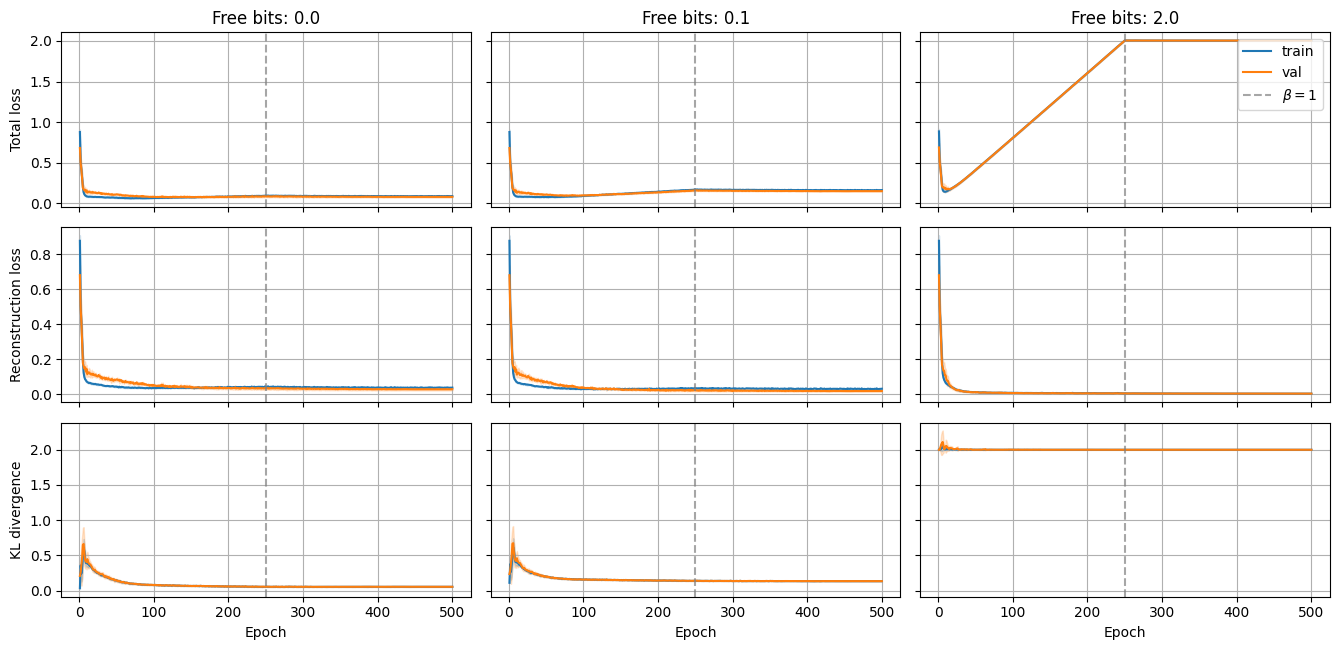

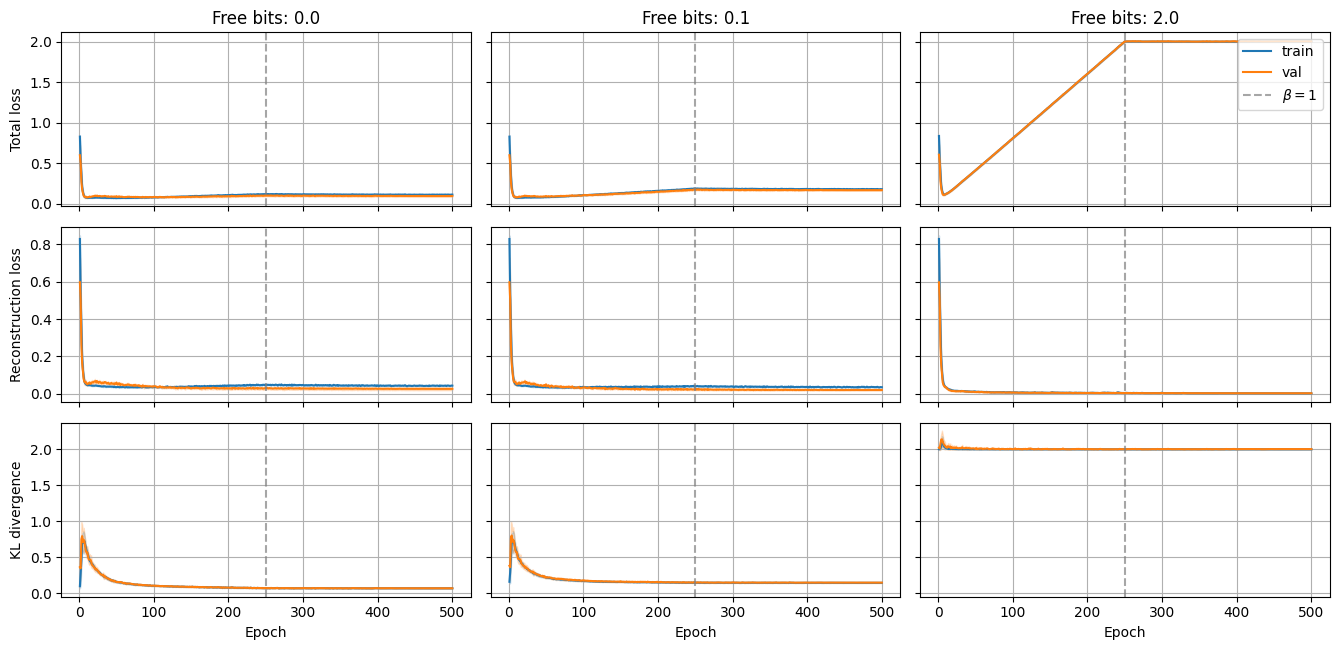

In [5]:
# training curves
pairs = [('train_loss', 'val_loss', 'Total loss'),
         ('train_recon', 'val_recon', 'Reconstruction loss'),
         ('train_kl', 'val_kl', 'KL divergence')]

for region in REGIONS:
    n_configs = len(FREE_BITS)
    n_rows = len(pairs)
    fig, axes = plt.subplots(n_rows, n_configs, figsize=(4.5 * n_configs, 2.2 * n_rows), sharex=True, sharey='row')

    for col, free_bit in enumerate(FREE_BITS):
        hists = [pd.read_csv(f'results/vae/{region}_s{seed}_ld{LATENT_DIM}_fb{free_bit}_train_history.csv') for seed in SEEDS]
        epochs = hists[0]['epoch'].values
        beta_one_median = int(np.median([h.loc[h['beta'] >= 1.0, 'epoch'].min() for h in hists]))

        for row, (tr_col, vl_col, title) in enumerate(pairs):
            ax = axes[row, col]
            for data_col, label, color in [(tr_col, 'train', 'tab:blue'), (vl_col, 'val', 'tab:orange')]:
                vals = np.stack([h[data_col].values for h in hists])
                mean = vals.mean(axis=0)
                std  = vals.std(axis=0)
                ax.plot(epochs, mean, label=label, color=color)
                ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)
            ax.axvline(beta_one_median, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
            if row == 0:
                ax.set_title(f'Free bits: {free_bit}')
            if col == 0:
                ax.set_ylabel(title)
            if row == n_rows - 1:
                ax.set_xlabel('Epoch')
            ax.legend(loc='upper right') if (row, col) == (0, n_configs - 1) else None
            ax.grid()

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_training_curves.pdf')
    plt.show()

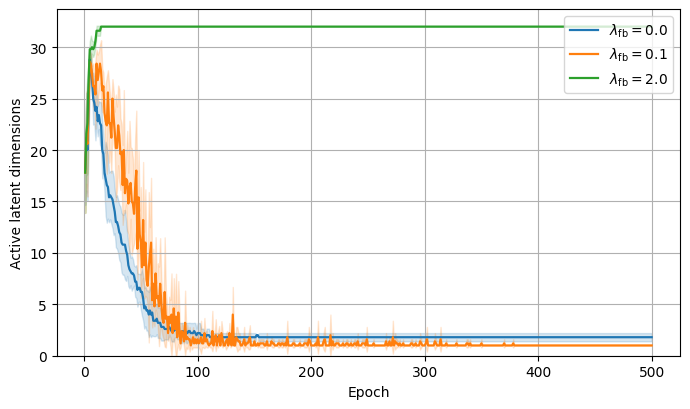

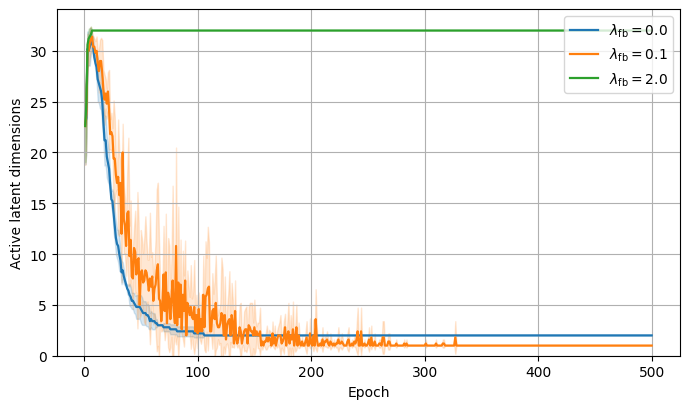

In [6]:
for region in REGIONS:
    fig, ax = plt.subplots(figsize=(7, 4.2))

    for free_bit in FREE_BITS:
        curves = []
        for seed in SEEDS:
            path = f'{RESULTS_DIR}/{region}_s{seed}_ld{LATENT_DIM}_fb{free_bit}_train_history.csv'
            df = pd.read_csv(path)
            curves.append(df['active_dims'].values)

        min_len = min(len(c) for c in curves)
        arr = np.stack([c[:min_len] for c in curves], axis=0)
        epochs = np.arange(1, min_len + 1)
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)

        color = FB_COLORS[free_bit]
        ax.plot(epochs, mean, color=color, linewidth=1.6, label=rf'$\lambda_\mathrm{{fb}} = {free_bit}$')
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.18)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Active latent dimensions')
    ax.set_ylim(bottom=0)
    ax.grid()
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_active_dims.pdf')
    plt.show()

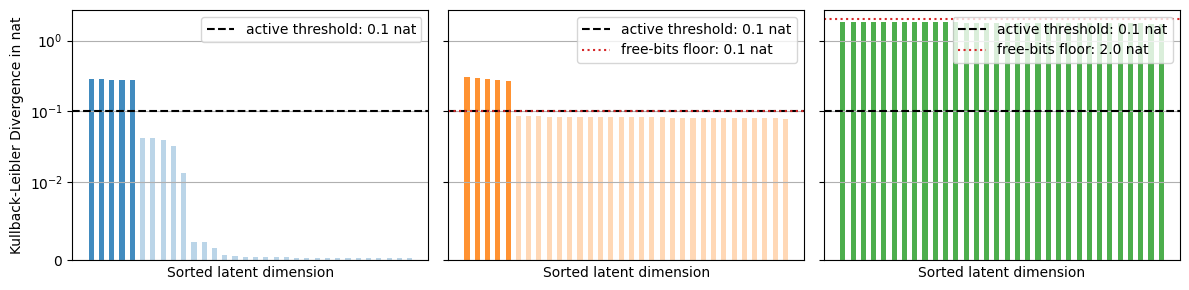

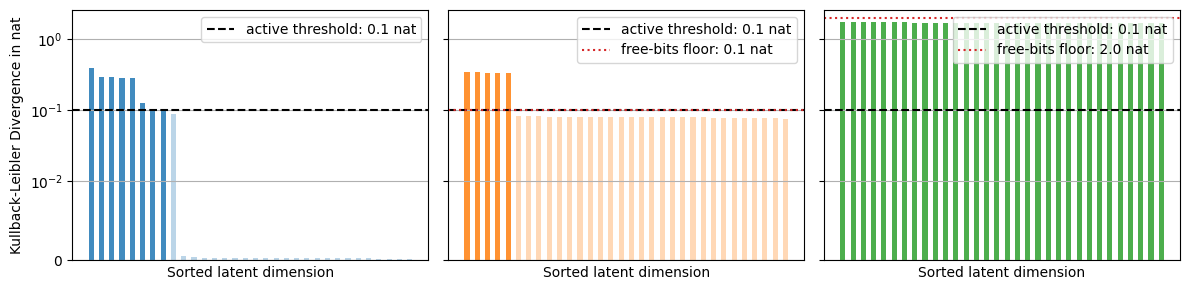

In [7]:
@torch.no_grad()
def encoder_outputs(model, train_ds):
    mus, logvars = [], []
    model.eval()
    for i in range(len(train_ds)):
        signal, *_ = train_ds[i]
        mu, logvar = model.encoder(signal.unsqueeze(0).to(device))
        mus.append(mu.squeeze(0).cpu())
        logvars.append(logvar.squeeze(0).cpu())
    return torch.stack(mus), torch.stack(logvars)

def per_dim_kl(mu, logvar):
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean(dim=0).numpy()

for region in REGIONS:
    fig, axes = plt.subplots(1, len(FREE_BITS), figsize=(4*len(FREE_BITS), 3), sharey=True)

    for ax, free_bit in zip(axes, FREE_BITS):
        kl_per_dim_seeds = []
        for seed in SEEDS:
            mu, logvar = encoder_outputs(models[seed][region][free_bit],
                                         datasets[seed][region]['train'])
            kl_per_dim_seeds.append(per_dim_kl(mu, logvar))

        kl_mean = np.mean(kl_per_dim_seeds, axis=0)
        order = np.argsort(kl_mean)[::-1]
        x = np.arange(len(kl_mean))
        n_active = int((kl_mean > ACTIVE_THRESHOLD).sum())

        color = FB_COLORS[free_bit]
        bars = ax.bar(x, kl_mean[order], width=0.5, color=color, alpha=0.85, edgecolor='none')
        for i, bar in enumerate(bars):
            if kl_mean[order][i] <= ACTIVE_THRESHOLD:
                bar.set_alpha(0.30)

        ax.axhline(ACTIVE_THRESHOLD, color='black', linestyle='--', label=f'active threshold: {ACTIVE_THRESHOLD} nat')
        if free_bit > 0:
            ax.axhline(free_bit, color='tab:red', linestyle=':', label=f'free-bits floor: {free_bit} nat')

        ax.set_yscale('symlog', linthresh=0.01)
        ax.set_xticks([])
        ax.set_xlabel('Sorted latent dimension')
        ax.grid(axis='y')
        ax.legend(loc='upper right')
        ax.set_ylabel('Kullback-Leibler Divergence in nat') if ax == axes[0] else None

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_kl_per_dim.pdf')
    plt.show()

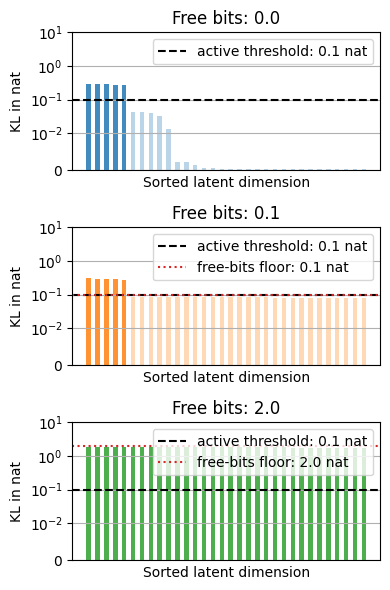

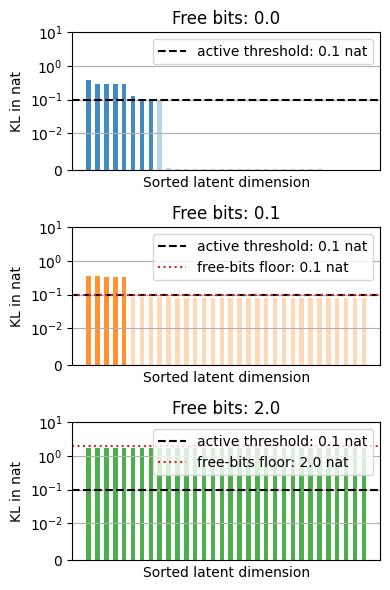

In [8]:
@torch.no_grad()
def encoder_outputs(model, train_ds):
    mus, logvars = [], []
    model.eval()
    for i in range(len(train_ds)):
        signal, *_ = train_ds[i]
        mu, logvar = model.encoder(signal.unsqueeze(0).to(device))
        mus.append(mu.squeeze(0).cpu())
        logvars.append(logvar.squeeze(0).cpu())
    return torch.stack(mus), torch.stack(logvars)

def per_dim_kl(mu, logvar):
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean(dim=0).numpy()

for region in REGIONS:
    fig, axes = plt.subplots(len(FREE_BITS), 1, figsize=(4, 2*len(FREE_BITS)), sharex=True)

    for ax, free_bit in zip(axes, FREE_BITS):
        kl_per_dim_seeds = []
        for seed in SEEDS:
            mu, logvar = encoder_outputs(models[seed][region][free_bit],
                                         datasets[seed][region]['train'])
            kl_per_dim_seeds.append(per_dim_kl(mu, logvar))

        kl_mean = np.mean(kl_per_dim_seeds, axis=0)
        order = np.argsort(kl_mean)[::-1]
        x = np.arange(len(kl_mean))
        n_active = int((kl_mean > ACTIVE_THRESHOLD).sum())

        color = FB_COLORS[free_bit]
        bars = ax.bar(x, kl_mean[order], width=0.5, color=color, alpha=0.85, edgecolor='none')
        for i, bar in enumerate(bars):
            if kl_mean[order][i] <= ACTIVE_THRESHOLD:
                bar.set_alpha(0.30)

        ax.axhline(ACTIVE_THRESHOLD, color='black', linestyle='--', label=f'active threshold: {ACTIVE_THRESHOLD} nat')
        if free_bit > 0:
            ax.axhline(free_bit, color='tab:red', linestyle=':', label=f'free-bits floor: {free_bit} nat')

        ax.set_yscale('symlog', linthresh=0.01)
        ax.set_xticks([])
        ax.set_xlabel('Sorted latent dimension')
        ax.set_title(f'Free bits: {free_bit}')
        ax.grid(axis='y')
        ax.legend(loc='upper right')
        ax.set_ylabel('KL in nat')
        ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_kl_per_dim.png', dpi=500)
    plt.show()

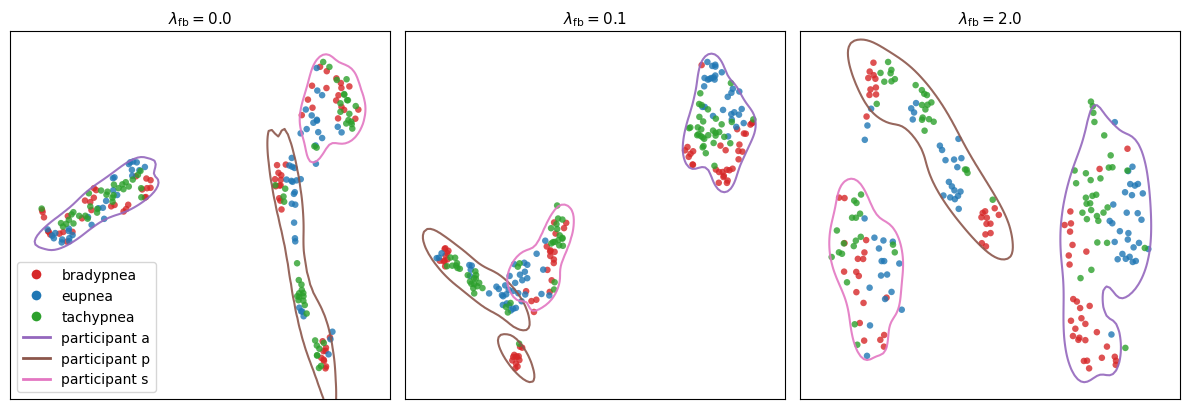

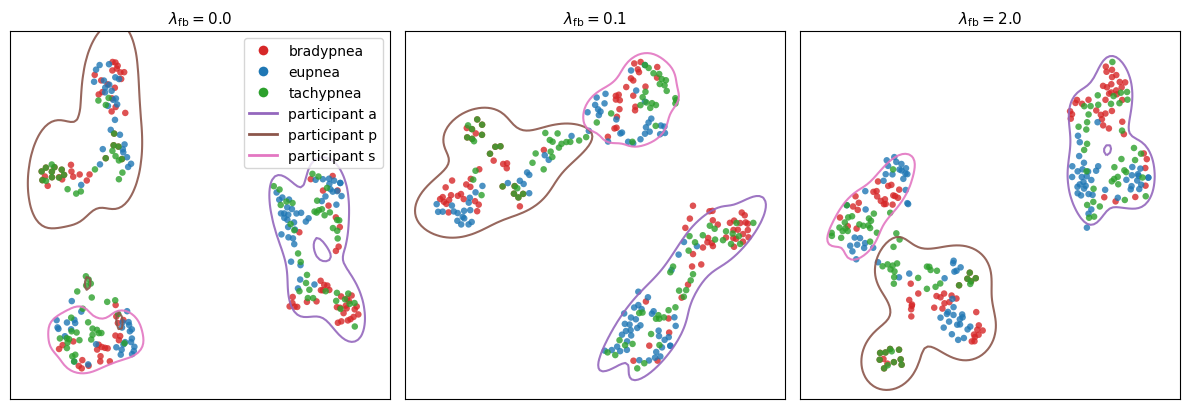

In [11]:

TSNE_MODEL_SEED = 0
TSNE_RANDOM_STATE = 0
PERPLEXITY = 30.0

class_colors = ['#d62728', '#1f77b4', '#2ca02c']  # brady, eupnea, tachy
part_colors  = ['#9467bd', '#8c564b', '#e377c2']  # a, p, s

def participant_contours(ax, emb, parts, colors, levels=(0.5,), grid_size=120, pad=0.1):
    """Overlay a KDE contour per participant at the specified density level(s)."""
    x_min, x_max = emb[:, 0].min(), emb[:, 0].max()
    y_min, y_max = emb[:, 1].min(), emb[:, 1].max()
    dx = (x_max - x_min) * pad
    dy = (y_max - y_min) * pad
    xx, yy = np.meshgrid(
        np.linspace(x_min - dx, x_max + dx, grid_size),
        np.linspace(y_min - dy, y_max + dy, grid_size),
    )
    grid = np.vstack([xx.ravel(), yy.ravel()])

    for pi, color in enumerate(colors):
        pts = emb[parts == pi]
        if len(pts) < 5:  # KDE needs a few points
            continue
        try:
            kde = gaussian_kde(pts.T)
        except np.linalg.LinAlgError:
            continue  # singular covariance (collinear points)
        density = kde(grid).reshape(xx.shape)
        # Convert "fraction of mass enclosed" to a density level
        flat = np.sort(density.ravel())[::-1]
        cumulative = np.cumsum(flat) / flat.sum()
        thresholds = [flat[np.searchsorted(cumulative, lvl)] for lvl in levels]
        ax.contour(xx, yy, density, levels=sorted(thresholds),
                   colors=[color], linewidths=1.5, alpha=0.9)


for region in REGIONS:
    train_ds = datasets[TSNE_MODEL_SEED][region]['train']
    classes = np.array([train_ds[i][2] for i in range(len(train_ds))])
    parts   = np.array([train_ds[i][3] for i in range(len(train_ds))])

    fig, axes = plt.subplots(1, len(FREE_BITS), figsize=(4 * len(FREE_BITS), 4.2))

    for c_idx, free_bit in enumerate(FREE_BITS):
        ax = axes[c_idx]
        mu, _ = encoder_outputs(models[TSNE_MODEL_SEED][region][free_bit], train_ds)
        mu = mu.numpy()

        eff_perp = min(PERPLEXITY, max(5, (len(mu) - 1) // 3))
        emb = TSNE(n_components=2, perplexity=eff_perp,
                   random_state=TSNE_RANDOM_STATE,
                   init='pca', learning_rate='auto').fit_transform(mu)

        # Points colored by class
        for ci, name in enumerate(CLASS_NAMES):
            mask = classes == ci
            ax.scatter(emb[mask, 0], emb[mask, 1], c=class_colors[ci],
                       label=name if c_idx == 0 else None,
                       s=22, alpha=0.8, edgecolors='none')

        # Contours per participant
        participant_contours(ax, emb, parts, part_colors, levels=(0.8,))
        # participant_contours(ax, emb, parts, part_colors)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(rf'$\lambda_\mathrm{{fb}} = {free_bit}$', fontsize=11)

    # Build a combined legend: classes (filled) + participants (line)
    from matplotlib.lines import Line2D
    class_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                            markersize=8, label=name)
                     for c, name in zip(class_colors, CLASS_NAMES)]
    part_handles = [Line2D([0], [0], color=c, linewidth=2,
                           label=f'participant {name}')
                    for c, name in zip(part_colors, PARTICIPANT_NAMES)]
    axes[0].legend(handles=class_handles + part_handles, loc='best', ncol=1)

    plt.tight_layout()
    plt.savefig(f'results/figures/05_{region}_tsne.png', dpi=500)
    plt.show()